# Time series 4: Phase encoding (position in the cycle)

Encode **where we are in the cycle** as features using sin/cos of phase:
- **Within the day**: sin(2π×hour/24), cos(2π×hour/24)
- **Within the week**: sin(2π×day_of_week/7), cos(2π×day_of_week/7)

Combined with lags [y(t-1), y(t-24), y(t-168)], we train **Ridge** and **MLP** to predict the next value. Same 1-step-ahead test set (last 8760 h); we report MAE and MASE vs naive and blend.

In [17]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor

_root = Path.cwd().resolve()
if _root.name == "time_series":
    _root = _root.parent
DATA_PATH = _root / "data" / "transformed" / "transformed_data.parquet"
if not DATA_PATH.exists():
    DATA_PATH = DATA_PATH.with_suffix(".csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Transform data not found at {DATA_PATH}. Run task transform first.")

df = pd.read_parquet(DATA_PATH) if DATA_PATH.suffix == ".parquet" else pd.read_csv(DATA_PATH)
df = df.sort_values(["date", "hour"]).reset_index(drop=True)
df["datetime"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="h")

freq_bands = sorted([c for c in df.columns if c not in ("date", "hour", "datetime")])
TEST_STEPS = 24 * 365
LAG24, LAG168 = 24, 168

print(f"Loaded {len(df)} rows. Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Frequency bands: {len(freq_bands)}")
print(f"Test window: last {TEST_STEPS} hours (1-step-ahead)")

Loaded 9192 rows. Date range: 2025-01-01 to 2026-01-18
Frequency bands: 70
Test window: last 8760 hours (1-step-ahead)


## Feature construction: lags + phase (sin/cos)

For each prediction we use:
- **Lags**: y(t-1), y(t-24), y(t-168)
- **Phase (target time)** — the hour we're predicting *for*:
  - hour_of_day ∈ [0,23] → sin(2π×h/24), cos(2π×h/24)
  - day_of_week ∈ [0,6] (Mon=0, Sun=6) → sin(2π×dow/7), cos(2π×dow/7)

So the model sees "where we are in the daily arc" and "where we are in the weekly arc" and can learn patterns like "hour 8 tends higher, hour 3 tends lower."

## Why does the phase model still lose? (Seasonality exists.)

In notebook 1 you saw **seasonality** (decomposition, daily/weekly pattern). So there *is* an essence of pattern per day. Two things explain why the phase model underperforms:

1. **1-step persistence dominates.** For the *next hour*, the last value y(t−1) is an extremely strong predictor. The seasonal component (e.g. "hour 8 tends higher") is real but **weaker than hour-to-hour autocorrelation** at 1-step. So naive (and blend) win on MAE even though seasonality exists.

2. **Phase encoding must be *learned* from data.** Sin/cos of hour tells the model *where* we are in the day, but Ridge/MLP still have to learn "at this phase, add this much." With 70 bands and limited training rows per band, that mapping can underfit or get wrong phase–level relationships. By contrast, the **blend** uses y(t−24) *directly* — it doesn't have to learn the daily shape, it just uses yesterday's value at the same hour.

Below we **identify the pattern per day** (mean value by hour, by day-of-week) so you can *see* the daily/weekly arc the phase encoding is trying to capture.

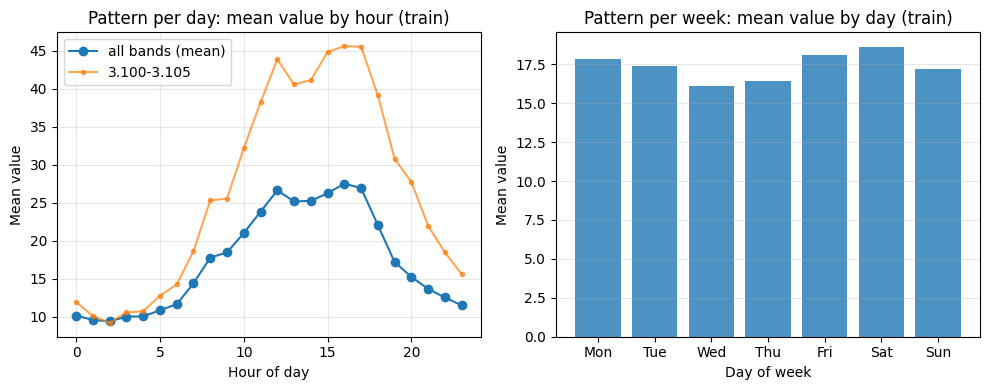

In [18]:
# Identify pattern per day: mean value by hour of day and by day of week (training data only)
train_df = df.iloc[: -TEST_STEPS].copy()
train_df["hour"] = train_df["datetime"].dt.hour
train_df["dayofweek"] = train_df["datetime"].dt.dayofweek  # 0=Mon, 6=Sun

# Pick one band and aggregate across bands for a "typical" daily profile
sample_band = freq_bands[0]
mean_by_hour = train_df.groupby("hour")[freq_bands].mean()
mean_by_hour_sample = mean_by_hour[sample_band]
mean_by_hour_agg = mean_by_hour.mean(axis=1)  # mean across all bands

mean_by_dow = train_df.groupby("dayofweek")[freq_bands].mean()
mean_by_dow_agg = mean_by_dow.mean(axis=1)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(mean_by_hour_agg.index, mean_by_hour_agg.values, "o-", label="all bands (mean)")
axes[0].plot(mean_by_hour_sample.index, mean_by_hour_sample.values, ".-", alpha=0.7, label=sample_band)
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Mean value")
axes[0].set_title("Pattern per day: mean value by hour (train)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
axes[1].bar(mean_by_dow_agg.index, mean_by_dow_agg.values, tick_label=dow_names, alpha=0.8)
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("Mean value")
axes[1].set_title("Pattern per week: mean value by day (train)")
axes[1].grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# If the daily curve has a clear shape (e.g. peak at certain hours), that's the pattern phase sin/cos is encoding.
# The phase model tries to learn "at this (sin_h, cos_h), predict this level" from limited per-band data.

In [19]:
def build_features_and_target(vals, dts, start_idx, end_idx_excl):
    """Build X (lags + phase sin/cos) and y for 1-step-ahead. Indices are relative to full series.
    For sample i we predict vals[i+1]; target datetime = dts[i+1]; lags use vals[i-1], vals[i-24], vals[i-168]."""
    X, y, datetimes = [], [], []
    for i in range(start_idx, end_idx_excl - 1):
        if i - LAG168 < 0:
            continue
        dt = pd.Timestamp(dts[i + 1])  # datetime we're predicting for
        h = dt.hour
        dow = dt.dayofweek  # 0=Monday, 6=Sunday
        sin_h = np.sin(2 * np.pi * h / 24)
        cos_h = np.cos(2 * np.pi * h / 24)
        sin_dow = np.sin(2 * np.pi * dow / 7)
        cos_dow = np.cos(2 * np.pi * dow / 7)
        feat = [vals[i - 1], vals[i - LAG24], vals[i - LAG168], sin_h, cos_h, sin_dow, cos_dow]
        X.append(feat)
        y.append(vals[i + 1])
        datetimes.append(dts[i + 1])
    return np.array(X, dtype=np.float64), np.array(y, dtype=np.float64), datetimes

def run_phase_model_per_band(model_factory):
    rows = []
    for freq in freq_bands:
        sub = df[["datetime", freq]].dropna(subset=[freq]).sort_values("datetime").reset_index(drop=True)
        if len(sub) < TEST_STEPS + LAG168 + 1:
            continue
        vals = sub[freq].values.astype(np.float64)
        dts = sub["datetime"].values
        T = len(vals) - TEST_STEPS
        train_vals, train_dts = vals[:T], dts[:T]
        test_vals, test_dts = vals[-TEST_STEPS:], dts[-TEST_STEPS:]
        X_tr, Y_tr, _ = build_features_and_target(vals, dts, LAG168, T)
        if len(X_tr) < 20:
            continue
        model = model_factory()
        model.fit(X_tr, Y_tr)
        for i in range(TEST_STEPS - 1):
            if T + i - LAG168 < 0:
                continue
            dt = pd.Timestamp(test_dts[i + 1])  # phase of the hour we're predicting for
            h, dow = dt.hour, dt.dayofweek
            sin_h = np.sin(2 * np.pi * h / 24)
            cos_h = np.cos(2 * np.pi * h / 24)
            sin_dow = np.sin(2 * np.pi * dow / 7)
            cos_dow = np.cos(2 * np.pi * dow / 7)
            feat = np.array([[vals[T + i - 1], vals[T + i - LAG24], vals[T + i - LAG168], sin_h, cos_h, sin_dow, cos_dow]])
            pred = model.predict(feat).item()
            rows.append({"datetime": test_dts[i + 1], "frequency_band": freq, "actual": test_vals[i + 1], "predicted": pred})
    return pd.DataFrame(rows)

print("Training Ridge and MLP with lags + phase (sin/cos hour, sin/cos day_of_week)...")
df_ridge_phase = run_phase_model_per_band(lambda: Ridge(alpha=1.0))
df_mlp_phase = run_phase_model_per_band(lambda: MLPRegressor(hidden_layer_sizes=(32, 16), max_iter=300, random_state=42))
print(f"Ridge (phase): {len(df_ridge_phase)} rows; MLP (phase): {len(df_mlp_phase)} rows")

Training Ridge and MLP with lags + phase (sin/cos hour, sin/cos day_of_week)...


/Users/pradeep/workspace/nikhita/cablelabs/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/pradeep/workspace/nikhita/cablelabs/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/pradeep/workspace/nikhita/cablelabs/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/pradeep/workspace/nikhita/cablelabs/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) 

Ridge (phase): 613130 rows; MLP (phase): 613130 rows


## Tune Ridge and MLP

Grid search over Ridge alpha and MLP architecture/iterations; keep the best config per model and overwrite `df_ridge_phase` and `df_mlp_phase` for downstream comparison.

In [20]:
# Tune Ridge: try several alphas; keep best by MAE
best_ridge_mae = np.inf
for alpha in [0.01, 0.1, 1.0, 10.0]:
    df_try = run_phase_model_per_band(lambda: Ridge(alpha=alpha))
    if len(df_try) == 0:
        continue
    mae = float(np.mean(np.abs(df_try["actual"] - df_try["predicted"])))
    if mae < best_ridge_mae:
        best_ridge_mae = mae
        df_ridge_phase = df_try
        best_ridge_alpha = alpha
print(f"Best Ridge: alpha = {best_ridge_alpha}, MAE = {best_ridge_mae:.4f}")

# Tune MLP: try (32,16) and (64,32), more iterations to reduce convergence warnings
best_mlp_mae = np.inf
for hidden, max_iter in [((32, 16), 500), ((64, 32), 500), ((32, 16), 800)]:
    df_try = run_phase_model_per_band(lambda: MLPRegressor(hidden_layer_sizes=hidden, max_iter=max_iter, random_state=42))
    if len(df_try) == 0:
        continue
    mae = float(np.mean(np.abs(df_try["actual"] - df_try["predicted"])))
    if mae < best_mlp_mae:
        best_mlp_mae = mae
        df_mlp_phase = df_try
        best_mlp_config = (hidden, max_iter)
print(f"Best MLP: hidden = {best_mlp_config[0]}, max_iter = {best_mlp_config[1]}, MAE = {best_mlp_mae:.4f}")

Best Ridge: alpha = 10.0, MAE = 5.4719


/Users/pradeep/workspace/nikhita/cablelabs/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/pradeep/workspace/nikhita/cablelabs/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/pradeep/workspace/nikhita/cablelabs/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/pradeep/workspace/nikhita/cablelabs/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) 

Best MLP: hidden = (64, 32), max_iter = 500, MAE = 4.5264


## Naive baseline (for comparison)

In [21]:
rows_naive = []
for freq in freq_bands:
    sub = df[["datetime", freq]].dropna(subset=[freq]).sort_values("datetime").reset_index(drop=True)
    if len(sub) < TEST_STEPS + 1:
        continue
    vals = sub[freq].values.astype(np.float64)
    dts = sub["datetime"].values
    test_vals, test_dts = vals[-TEST_STEPS:], dts[-TEST_STEPS:]
    for i in range(0, TEST_STEPS - 1):
        rows_naive.append({"datetime": test_dts[i+1], "frequency_band": freq, "actual": test_vals[i+1], "predicted": test_vals[i]})
df_naive = pd.DataFrame(rows_naive)

def mase_from_df(pred_df):
    diffs = pred_df.sort_values(["frequency_band", "datetime"]).groupby("frequency_band")["actual"].diff().dropna().abs()
    denom = float(diffs.mean()) if len(diffs) > 0 else np.nan
    mae = float(np.mean(np.abs(pred_df["actual"] - pred_df["predicted"])))
    return mae / denom if denom and denom > 0 else np.nan

mae_naive = float(np.mean(np.abs(df_naive["actual"] - df_naive["predicted"])))
mase_naive = mase_from_df(df_naive)
print(f"Naive:  MAE = {mae_naive:.4f},  MASE = {mase_naive:.4f}" if not np.isnan(mase_naive) else f"Naive:  MAE = {mae_naive:.4f}")

Naive:  MAE = 2.4198,  MASE = 0.9999


## Results: phase-encoding models vs naive

In [22]:
mae_ridge = float(np.mean(np.abs(df_ridge_phase["actual"] - df_ridge_phase["predicted"])))
mae_mlp = float(np.mean(np.abs(df_mlp_phase["actual"] - df_mlp_phase["predicted"])))
mase_ridge = mase_from_df(df_ridge_phase)
mase_mlp = mase_from_df(df_mlp_phase)

print("=== 1-step-ahead: Lags + phase (sin/cos) vs Naive ===")
print(f"  Naive:           MAE = {mae_naive:.4f},  MASE = {mase_naive:.4f}" if not np.isnan(mase_naive) else f"  Naive:           MAE = {mae_naive:.4f}")
print(f"  Ridge (phase):   MAE = {mae_ridge:.4f},  MASE = {mase_ridge:.4f}" if not np.isnan(mase_ridge) else f"  Ridge (phase):   MAE = {mae_ridge:.4f}")
print(f"  MLP (phase):     MAE = {mae_mlp:.4f},  MASE = {mase_mlp:.4f}" if not np.isnan(mase_mlp) else f"  MLP (phase):     MAE = {mae_mlp:.4f}")
print()
best_mae = min(mae_naive, mae_ridge, mae_mlp)
if mae_ridge < mae_naive or mae_mlp < mae_naive:
    print("  → At least one phase-encoding model beats naive.")
else:
    print("  → Naive still best; phase encoding helps the model learn the arc but may not beat persistence at 1-step.")

=== 1-step-ahead: Lags + phase (sin/cos) vs Naive ===
  Naive:           MAE = 2.4198,  MASE = 0.9999
  Ridge (phase):   MAE = 5.4719,  MASE = 2.2611
  MLP (phase):     MAE = 4.5264,  MASE = 1.8704

  → Naive still best; phase encoding helps the model learn the arc but may not beat persistence at 1-step.


## Compare: blend only vs blend + phase

- **Blend only**: winning model 0.91×naive + 0.09×seasonal (no phase).
- **Blend + phase**: combine blend with the best phase-encoding model (Ridge or MLP): pred = β×blend + (1−β)×phase; tune β.

We compute MAE/MASE for both on the **same test set** and compare.

In [23]:
# Build winning blend (α=0.91): 0.91*naive + 0.09*seasonal
ALPHA_BLEND = 0.91
rows_naive_b, rows_seasonal_b = [], []
for freq in freq_bands:
    sub = df[["datetime", freq]].dropna(subset=[freq]).sort_values("datetime").reset_index(drop=True)
    if len(sub) < TEST_STEPS + 24:
        continue
    vals = sub[freq].values.astype(np.float64)
    dts = sub["datetime"].values
    test_vals = vals[-TEST_STEPS:]
    test_dts = dts[-TEST_STEPS:]
    for i in range(0, TEST_STEPS - 1):
        rows_naive_b.append({"datetime": test_dts[i+1], "frequency_band": freq, "actual": test_vals[i+1], "predicted": test_vals[i]})
    for i in range(23, TEST_STEPS - 1):
        rows_seasonal_b.append({"datetime": test_dts[i+1], "frequency_band": freq, "actual": test_vals[i+1], "predicted": test_vals[i-23]})
df_naive_b = pd.DataFrame(rows_naive_b).rename(columns={"predicted": "p_naive"})[["datetime", "frequency_band", "actual", "p_naive"]]
df_seasonal_b = pd.DataFrame(rows_seasonal_b).rename(columns={"predicted": "p_seasonal"})[["datetime", "frequency_band", "p_seasonal"]]
merge_b = df_naive_b.merge(df_seasonal_b, on=["datetime", "frequency_band"], how="inner")
merge_b["blend_pred"] = ALPHA_BLEND * merge_b["p_naive"] + (1 - ALPHA_BLEND) * merge_b["p_seasonal"]

# Pick better phase model (Ridge vs MLP) by MAE
mae_ridge = float(np.mean(np.abs(df_ridge_phase["actual"] - df_ridge_phase["predicted"])))
mae_mlp = float(np.mean(np.abs(df_mlp_phase["actual"] - df_mlp_phase["predicted"])))
df_phase = df_ridge_phase if mae_ridge <= mae_mlp else df_mlp_phase
phase_name = "Ridge (phase)" if mae_ridge <= mae_mlp else "MLP (phase)"
df_phase = df_phase.rename(columns={"predicted": "phase_pred"})[["datetime", "frequency_band", "actual", "phase_pred"]]

# Merge blend and phase on (datetime, frequency_band)
combo = merge_b[["datetime", "frequency_band", "actual", "blend_pred"]].merge(
    df_phase[["datetime", "frequency_band", "phase_pred"]], on=["datetime", "frequency_band"], how="inner"
)

# Tune β: combined = β*blend + (1-β)*phase
best_beta, best_mae_combo = 0.5, np.inf
for beta in np.linspace(0, 1, 21):
    pred_combo = beta * combo["blend_pred"] + (1 - beta) * combo["phase_pred"]
    mae = float(np.mean(np.abs(combo["actual"] - pred_combo)))
    if mae < best_mae_combo:
        best_mae_combo = mae
        best_beta = beta
combo["predicted"] = best_beta * combo["blend_pred"] + (1 - best_beta) * combo["phase_pred"]
mase_combo = mase_from_df(combo[["datetime", "frequency_band", "actual", "predicted"]])

# Blend-only on the same rows (fair comparison)
mae_blend_only = float(np.mean(np.abs(combo["actual"] - combo["blend_pred"])))
combo_blend_only = combo[["datetime", "frequency_band", "actual"]].copy()
combo_blend_only["predicted"] = combo["blend_pred"]
mase_blend_only = mase_from_df(combo_blend_only)

print("=== Blend vs Blend + phase (same test set) ===")
print(f"  Blend (α=0.91) only:     MAE = {mae_blend_only:.4f},  MASE = {mase_blend_only:.4f}" if not np.isnan(mase_blend_only) else f"  Blend (α=0.91) only:     MAE = {mae_blend_only:.4f}")
print(f"  Blend + phase (β={best_beta:.2f}):  MAE = {best_mae_combo:.4f},  MASE = {mase_combo:.4f}" if not np.isnan(mase_combo) else f"  Blend + phase (β={best_beta:.2f}):  MAE = {best_mae_combo:.4f}")
print(f"  (Phase model in combo: {phase_name})")
print()
if best_mae_combo < mae_blend_only:
    pct = 100 * (mae_blend_only - best_mae_combo) / mae_blend_only
    print(f"  → Blend + phase wins: {pct:.2f}% lower MAE than blend only.")
elif best_mae_combo > mae_blend_only:
    print("  → Blend only wins; adding phase did not help on this test set.")
else:
    print("  → Tie; blend + phase matches blend only (e.g. β=1).")

=== Blend vs Blend + phase (same test set) ===
  Blend (α=0.91) only:     MAE = 2.3900,  MASE = 0.9884
  Blend + phase (β=1.00):  MAE = 2.3900,  MASE = 0.9884
  (Phase model in combo: MLP (phase))

  → Tie; blend + phase matches blend only (e.g. β=1).
